# Рекомендательная система для управления онлайн-сообществами
## Введение
Данный документ описывает задачу разработки алгоритма рекомендаций для платформы управления онлайн-сообществами. Платформа анализирует онлайн-сообщества — выявляет потенциальные проблемы и возможности роста, создаёт аналитические метрики и отчёты. Миссия продукта — превратить управление сообществом из трудоёмкого процесса, основанного на догадках, в простой и основанный на данных процесс, обеспечивающий измеримую ценность для бизнеса.

## Постановка задачи
Разработать алгоритм, который на основе данных конкретного сообщества говорит управляющему, влияние на что в сообществе даст наибольший результат.

Управляющий сообществом создаёт инициативы: просит участников помочь с тем или иным, связывается лично, приветствует новичков, модерирует форум. Любая рекомендация системы в конечном счёте выражается в коммуникации с пользователями. Поэтому система рекомендует не абстрактные улучшения, а конкретные действия: с кем говорить, что улучшить и к чему это приведёт в измеримых показателях.

Технически задача формулируется так: оценить, как те или иные параметры сообщества влияют на целевые переменные, оценить потенциал изменения этих параметров и рекомендовать то, что даст наибольший эффект. Эффект выражается в количестве пользователей и уровне их удержания.

## Данные

### Типы сообществ
Система обучается на данных 36 сообществ двух типов:

Q&A форумы (20 сообществ) — форум вопрос-ответ
Чаты (10 сообществ) — чат-сообщества

Оба типа анализируются отдельно, поскольку поведение пользователей и механизмы вовлечения в них принципиально различаются.

### Структура сырых данных
- topic_id - идентификационный номер топика. Топик состоит из одного вопроса и всех ответов  к нему
- id — идентификационный номер поста
- parent_id — идентификационный номер родительского поста для ответов или -1 для вопросов
- post_type — тип поста. Посты бывают только двух типов: вопрос — 1, ответ — 2.
- created_at — дата создания публикации
- author_id — идентификационный номер автора поста
- post_count - количество постов в вопросе
- view_count - количество просмотров
- reply_time - время ответа
- is_accepted_answer - ответ на вопрос?
- author_username - имя пользователя

In [1]:
import pandas as pd
display((pd.read_csv(r'..\data\raw_data\elastic.csv').head(3)))

,Unnamed: 0,topic_id,id,parent_id,post_type,posts_count,view_count,created_at,reply_time,is_accepted_answer,author_id,author_username
0,0,81971,260702,-1,1,5,12,2017-04-11 11:28:46.182000+00:00,0.00,False,33550,debashree13
1,1,81971,261035,260702,2,0,0,2017-04-12 01:22:44.875000+00:00,0.58,False,1144,eperry
2,2,81971,261157,260702,2,0,0,2017-04-12 07:34:49.587000+00:00,0.84,False,33550,debashree13


### Панельный датасет
На основе сырых данных сформирован панельный датасет: одна строка соответствует одному сообществу за один месяц. Итоговый объём — 4521 наблюдение (для Q&A) и 1036 наблюдений (для чатов) по 51 переменной. Каждое наблюдение включает рассчитанные метрики, их динамику (MoM, YoY), стадию жизненного цикла и тип сообщества.

In [2]:
df_qa = pd.read_pickle(r"model/df_qa.pkl")
df_chat = pd.read_pickle(r"model/df_chat.pkl")
df_chat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1036 entries, 0 to 5270
Data columns (total 75 columns):
 #   Column                                              Non-Null Count  Dtype    
---  ------                                              --------------  -----    
 0   community_id                                        1036 non-null   object   
 1   month                                               1036 non-null   period[M]
 2   stage                                               1036 non-null   object   
 3   type                                                1036 non-null   object   
 4   mau                                                 930 non-null    float64  
 5   mau_mom                                             880 non-null    float64  
 6   mau_yoy                                             804 non-null    float64  
 7   d7                                                  885 non-null    float64  
 8   d7_mom                                              812 non-nul

## Метрики
### Целевые метрики (таргеты) - менеджер не влияет напрямую
- MAU - количество уникальных пользователей с хотя бы одним действием за месяц. Основной показатель размера аудитории
- monthly_retention - доля пользователей прошлого месяца, вернувшихся в текущем. Показывает, насколько сообщество удерживает аудиторию
- total_number_of_actions - Общее число действий за месяц
- new_user_d7_retention - Доля новичков, вернувшихся в течении 7 дней
- new_user_d30_retention - Доля новичков, вернувшихся в течении 30 дней

### Управляемые метрики (предикторы) - менеджер влияет напрямую

- number_of_regular_users - Число постоянно активных участников
- core_contribution_share - Доля контента от топ-10% пользователей
- reactivated_users_count - Пользователи, вернувшиеся после неактивности
- new_user_activation_rate - Процент новичков с повторным действием
- newcomer_no_response_rate_1h - Доля новичков без ответа в первый час
- newcomer_median_time_to_first_response_minutes - Медианное время до первого ответа новичку
- newcomer_first_day_response_rate - Доля новичков, получивших ответ в первый день
- percentage_new_users_receiving_first_reply - Процент новичков с хотя бы одним ответом
- median_time_to_first_reply - Медианное время до первого ответа в топике
- median_time_to_be_answered - Медианное время до принятого ответа
- unanswered_rate - Доля вопросов без единого ответа
- average_replies_per_topic - Среднее число ответов на обсуждение
- average_thread_messages - Среднее число сообщений в треде
- resolution_rate - Доля вопросов с принятым ответом
- answered_but_unresolved_rate - Ответы есть, но вопрос не закрыт

### Дополнительные метрики (информационные) 
Эти метрики отображаются менеджеру для понимания общего состояния сообщества, но не используются напрямую в модели рекомендаций.

- user_churn - Процент ушедших пользователей
- stickiness - Отношение DAU к MAU
- number_of_posts_discussions - Число новых обсуждений за месяц
- mom, yoy - значение метрики за текущий и прошлый (месячный и годичный) период

## Пустые значения

В некоторых датасетах есть месяцы, когда активности не было и значеняи метрик нулевые.

Также некоторые сеты имеются is_accepted_answer == False (сообщество формата чата) и метрики имеют NaN

## Стадии жизненного цикла сообщества
Каждому наблюдению присваивается стадия на основе темпа роста MAU и баланса притока/оттока пользователей:

| Стадия       | Критерий                           | Характеристика                   |
|--------------|------------------------------------|----------------------------------|
| Growth       | `mau_mom > 10%`                    | Активный рост аудитории          |
| Stagnation   | `-5% < mau_mom < 10%` при слабом балансе | Нет ни роста, ни спада       |
| Decline      | `mau_mom < -5%`                    | Устойчивое падение аудитории      |

Стадия определяет, какие рекомендации актуальны: на росте важно удерживать новичков, на стагнации — активировать их, на спаде — снижать отток.

In [3]:
pivots_table = pd.read_pickle("model/pivots_table.pkl")
df_model = pd.read_pickle(r"model/df_model.pkl")

In [4]:
# Разделяем датафрейм на два разных (q&a и чат)
df_qa = df_model[df_model['type'] == 'qa'].copy()
df_chat = df_model[df_model['type'] == 'chat'].copy()

In [5]:
#Определяем структуру 
# Таргеты - смотрим что будет в СЛЕДУЮЩЕМ месяце

targets = [
    'mau',
    'monthly_retention',
    'total_number_of_actions',
    'd7',
    'd30',
]

# Предикторы — текущее значение управляемых метрик
predictors = [
    'number_of_regular_users',
    'core_contribution_share',
    'reactivated_users_count',
    'new_user_activation_rate_7d',
    'newcomer_no_response_rate_1h',
    'newcomer_median_time_to_first_response_minutes',
    'newcomer_first_day_response_rate',
    'percentage_new_users_receiving_first_reply',
    'median_time_to_first_reply_hours',
    'median_time_to_be_answered_hours',
    'unanswered_rate',
    'average_replies_per_discussion',
    'average_thread_messages',
    'resolution_rate',
    'answered_but_unresolved_rate',
]

# Контрольные переменные
controls = ['stage', 'type', 'community_id']

#Стадии сообщества
stages = ['growth', 'mature', 'stagnation', 'decline']

In [6]:
# Лаговая структура — предиктор текущего месяца, таргет следующего
df_chat = df_chat.sort_values(['community_id', 'month']).copy()

# Создаем таргеты следующего месяца
df_chat['mau_next'] = df_chat.groupby('community_id')['mau'].shift(-1)
df_chat['monthly_retention_next'] = df_chat.groupby('community_id')['monthly_retention'].shift(-1)
df_chat['total_number_of_actions_next'] = df_chat.groupby('community_id')['total_number_of_actions'].shift(-1)
df_chat['d7_next'] = df_chat.groupby('community_id')['d7'].shift(-1)
df_chat['d30_next'] = df_chat.groupby('community_id')['d30'].shift(-1)

# Убираем последний месяц каждого сообщества (нет след периода)
df_chat = df_chat[df_chat[f'{targets[0]}_next'].notna()].copy()

# Итоговые колонки для анализа
feature_cols  = predictors + controls
target_cols   = [f'{t}_next' for t in targets]

print(df_chat[feature_cols + target_cols].info())

<class 'pandas.core.frame.DataFrame'>
Index: 924 entries, 0 to 5269
Data columns (total 23 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   number_of_regular_users                         812 non-null    float64
 1   core_contribution_share                         880 non-null    float64
 2   reactivated_users_count                         880 non-null    float64
 3   new_user_activation_rate_7d                     841 non-null    float64
 4   newcomer_no_response_rate_1h                    841 non-null    float64
 5   newcomer_median_time_to_first_response_minutes  841 non-null    float64
 6   newcomer_first_day_response_rate                841 non-null    float64
 7   percentage_new_users_receiving_first_reply      552 non-null    float64
 8   median_time_to_first_reply_hours                689 non-null    float64
 9   median_time_to_be_answered_hours               

In [7]:
# Сколько наблюдений в каждой стадии
print(df_chat['stage'].value_counts())

# Пропуски по каждому новому предиктору
print(df_chat[predictors].isna().sum())

stage
decline       338
growth        298
stagnation    264
mature         24
Name: count, dtype: int64
number_of_regular_users                           112
core_contribution_share                            44
reactivated_users_count                            44
new_user_activation_rate_7d                        83
newcomer_no_response_rate_1h                       83
newcomer_median_time_to_first_response_minutes     83
newcomer_first_day_response_rate                   83
percentage_new_users_receiving_first_reply        372
median_time_to_first_reply_hours                  235
median_time_to_be_answered_hours                  885
unanswered_rate                                   231
average_replies_per_discussion                    231
average_thread_messages                            44
resolution_rate                                   231
answered_but_unresolved_rate                      231
dtype: int64


Проблемы которые сразу выявлены:

1) median_time_to_be_answered_hours: 790 пропусков
Это ~96% всех строк в df_chat. 
Метрика фактически отсутствует для чатов — логично, в Discord нет понятия «принятый ответ». Убираем из анализа чатов полностью.

2) 186 пропусков одновременно у пяти метрик:
median_time_to_first_reply_hours, unanswered_rate, average_replies_per_discussion, resolution_rate, answered_but_unresolved_rate
Одинаковое число пропусков — это одни и те же строки. Скорее всего это Q&A метрики, которые не считались для чатов. Проверяем:

3) percentage_new_users_receiving_first_reply: 314 пропусков (38%)

4) mature: 21 наблюдение — объединяем со stagnation:


In [8]:
df_chat['stage'] = df_chat['stage'].replace({'mature': 'stagnation'})

In [9]:
# Убираем из списка предикторов для chat
predictors_chat = [p for p in predictors 
                   if p != 'median_time_to_be_answered_hours']

Повторяем тоже самое для df_qa

In [10]:
# Лаговая структура — предиктор текущего месяца, таргет следующего
df_qa = df_qa.sort_values(['community_id', 'month']).copy()

# Создаем таргеты следующего месяца
df_qa['mau_next'] = df_qa.groupby('community_id')['mau'].shift(-1)
df_qa['monthly_retention_next'] = df_qa.groupby('community_id')['monthly_retention'].shift(-1)
df_qa['total_number_of_actions_next'] = df_qa.groupby('community_id')['total_number_of_actions'].shift(-1)
df_qa['d7_next'] = df_qa.groupby('community_id')['d7'].shift(-1)
df_qa['d30_next'] = df_qa.groupby('community_id')['d30'].shift(-1)

# Убираем последний месяц каждого сообщества (нет след периода)
df_qa = df_qa[df_qa[f'{targets[0]}_next'].notna()].copy()

# Итоговые колонки для анализа
feature_cols  = predictors + controls
target_cols   = [f'{t}_next' for t in targets]

print(df_qa[feature_cols + target_cols].info())

<class 'pandas.core.frame.DataFrame'>
Index: 4285 entries, 230 to 5555
Data columns (total 23 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   number_of_regular_users                         4004 non-null   float64
 1   core_contribution_share                         4214 non-null   float64
 2   reactivated_users_count                         4214 non-null   float64
 3   new_user_activation_rate_7d                     4184 non-null   float64
 4   newcomer_no_response_rate_1h                    4184 non-null   float64
 5   newcomer_median_time_to_first_response_minutes  4184 non-null   float64
 6   newcomer_first_day_response_rate                4184 non-null   float64
 7   percentage_new_users_receiving_first_reply      3990 non-null   float64
 8   median_time_to_first_reply_hours                4089 non-null   float64
 9   median_time_to_be_answered_hours            

In [11]:
# Сколько наблюдений в каждой стадии
print(df_qa['stage'].value_counts())

# Пропуски по каждому новому предиктору
print(df_qa[predictors].isna().sum())

stage
stagnation    1535
decline       1398
growth        1169
mature         183
Name: count, dtype: int64
number_of_regular_users                            281
core_contribution_share                             71
reactivated_users_count                             71
new_user_activation_rate_7d                        101
newcomer_no_response_rate_1h                       101
newcomer_median_time_to_first_response_minutes     101
newcomer_first_day_response_rate                   101
percentage_new_users_receiving_first_reply         295
median_time_to_first_reply_hours                   196
median_time_to_be_answered_hours                  1399
unanswered_rate                                    190
average_replies_per_discussion                     190
average_thread_messages                             71
resolution_rate                                    190
answered_but_unresolved_rate                       190
dtype: int64


Как и ожидалось, единственная проблема с mature. Объединяем со стадией stagnation
median_time_to_be_answered_hours 32.6% пропусков - оставляем


In [12]:
df_qa['stage'] = df_qa['stage'].replace({'mature': 'stagnation'})
predictors_qa = predictors



In [13]:
stages = ['growth', 'stagnation', 'decline']

## Корреляционный анализ

### Цель
Определить какие управляемые метрики включать в рекомендательную модель. Для этого нужно ответить на три вопроса:
1) Есть ли связь между предиктором и таргетом?
2) Правильный ли знак — направление связи логично?
3) Не дублирует ли предиктор другой предиктор?

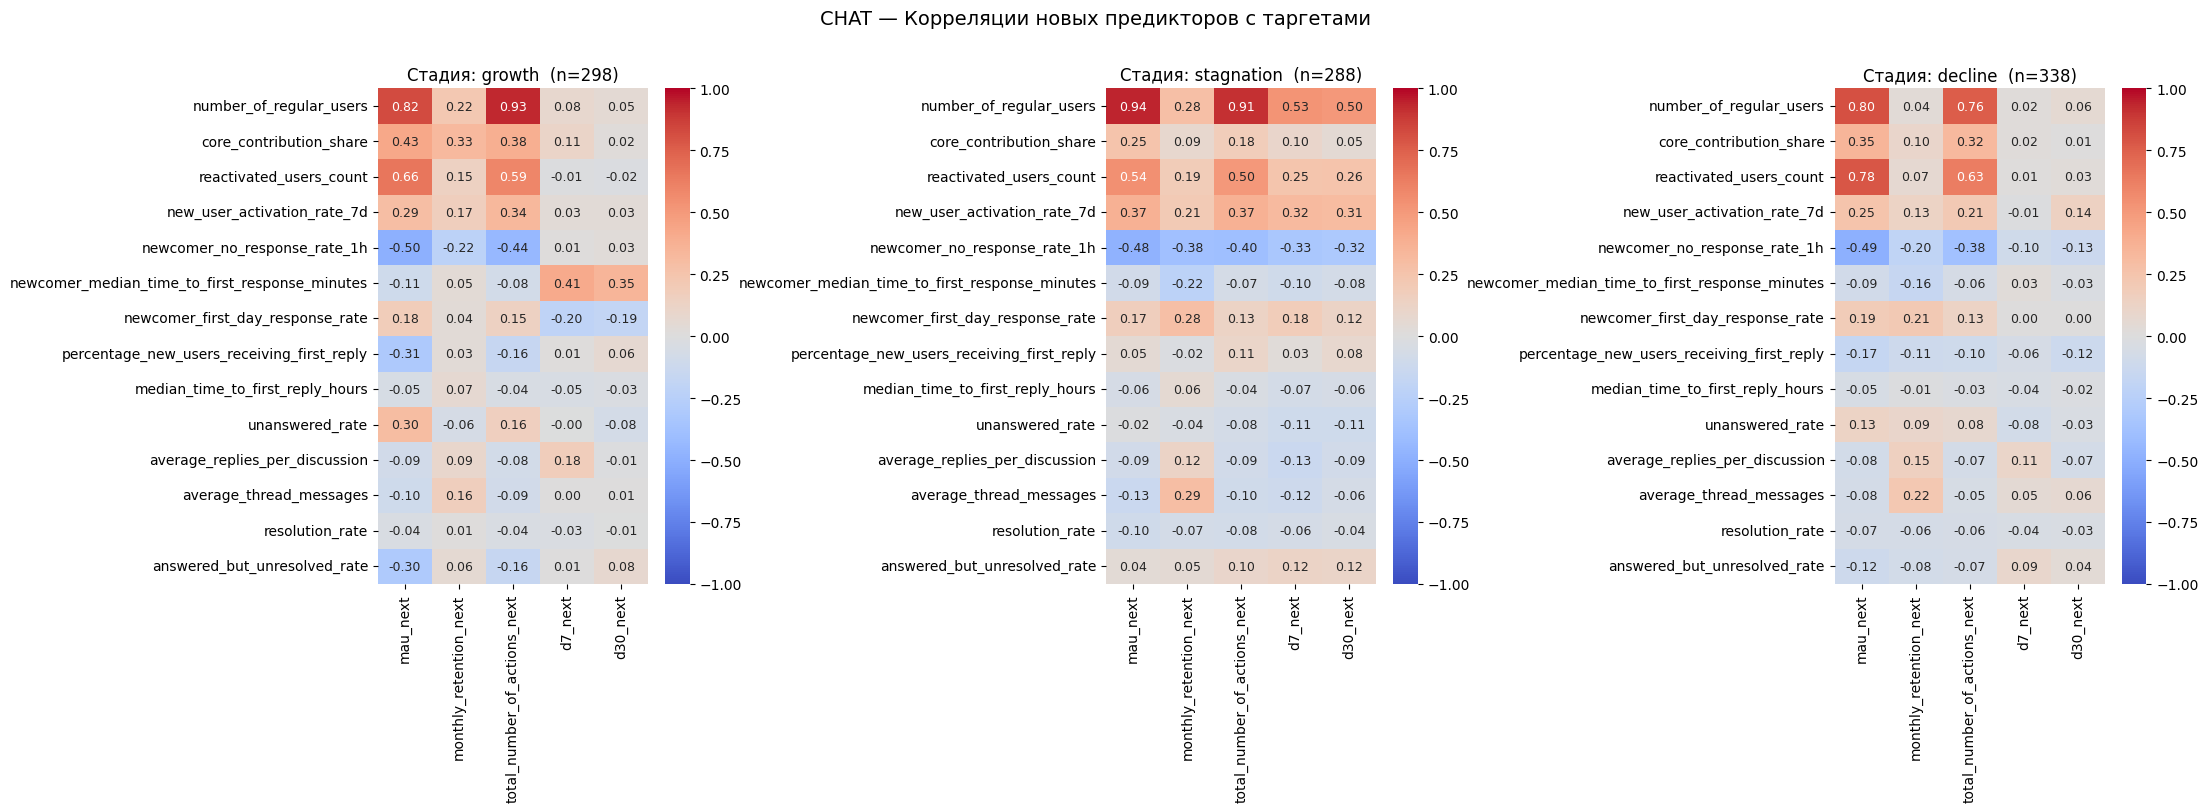

In [14]:
# Корреляции предикторов с таргетами по стадиям для чатов
# Это основной шаг. Смотрим силу и направление связи отдельно для каждой стадии и каждого типа сообщества.
import seaborn as sns
import matplotlib.pyplot as plt

for community_type, df_type in [('chat', df_chat)]:
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    
    for i, stage in enumerate(stages):
        df_stage = df_type[df_type['stage'] == stage]
        
        corr = df_stage[predictors_chat + target_cols]\
            .corr(method='pearson')\
            .loc[predictors_chat, target_cols]
        
        n = len(df_stage)
        
        sns.heatmap(
            corr,
            annot=True, fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1, center=0,
            ax=axes[i],
            annot_kws={'size': 9}
        )
        axes[i].set_title(f'Стадия: {stage}  (n={n})', fontsize=12)
    
    plt.suptitle(f'{community_type.upper()} — Корреляции новых предикторов с таргетами',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [15]:
print(df_chat[['number_of_regular_users', 'mau']].corr())
print(df_chat[['reactivated_users_count', 'mau']].corr())

                         number_of_regular_users      mau
number_of_regular_users                  1.00000  0.92469
mau                                      0.92469  1.00000
                         reactivated_users_count       mau
reactivated_users_count                 1.000000  0.642457
mau                                     0.642457  1.000000


### Подвывод для чатов
1) number_of_regular_users — убираем
Корреляция 0.925 с текущим MAU — это фактически одна и та же метрика. Регулярные пользователи это просто подмножество MAU. Даже с лаговой структурой мы будем предсказывать MAU следующего месяца из MAU текущего месяца, просто под другим названием.

2) reactivated_users_count — проблема масштаба
0.614 с текущим MAU — умеренная корреляция, но здесь другая проблема. В большом сообществе реактивированных пользователей абсолютно больше просто потому что сообщество большое. Метрика измеряет масштаб, а не эффективность работы менеджера.
Решение — нормализовать:

In [16]:
# Вместо абсолютного числа берём долю реактивированных от MAU
df_chat['reactivated_rate'] = (
    df_chat['reactivated_users_count'] / df_chat['mau']
)

df_chat['reactivated_rate'] = (
    df_chat['reactivated_users_count'] / df_chat['mau']
)

# Проверяем корреляцию с MAU после нормализации
print(df_chat[['reactivated_rate', 'mau']].corr())

                  reactivated_rate      mau
reactivated_rate           1.00000 -0.26538
mau                       -0.26538  1.00000


3) Список контринтуитивных знаков из нашего анализа
    1. percentage_new_users_receiving_first_reply → MAU: отрицательный
Ожидали: больше новичков с ответом → выше MAU. Получили: отрицательный.
Возможные причины: В больших активных чатах поток сообщений высокий → новички теряются → меньше получают ответ. При этом MAU растёт за счёт объёма
Обратная причинность: высокий MAU создаёт условия где труднее отвечать каждому новичку

    2. unanswered_rate → MAU: положительный в growth
Ожидали: больше без ответа → хуже для сообщества. Получили: положительный.
Возможные причины: На стадии growth поток новых вопросов растёт быстрее чем успевают отвечать — это просто следствие роста, а не его причина
Снова обратная причинность: рост MAU порождает больше вопросов без ответа

    3. core_contribution_share → MAU: положительный
Ожидали: концентрация контента в руках немногих это риск, должна быть отрицательной. Получили: положительный.
Возможные причины: В чатах несколько активных людей создают «ядро» контента которое привлекает остальных
Для форумов логика другая — там концентрация действительно риск

    4. answered_but_unresolved_rate → MAU: отрицательный в growth
Ожидали: вопросы с ответами но не закрытые — нейтрально или положительно. Получили: отрицательный.

Как проверить — причина или следствие
Для каждой метрики строим scatter plot с лаговой структурой:

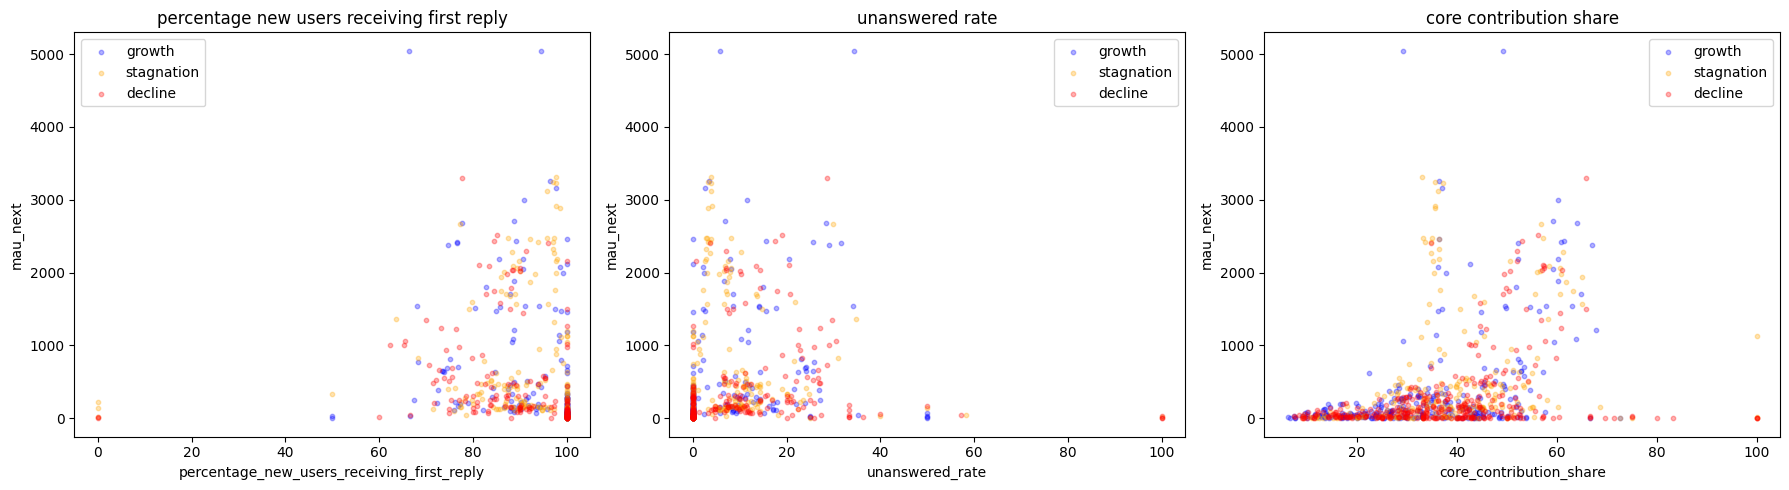

In [17]:
suspicious = {
    'percentage_new_users_receiving_first_reply': 'mau_next',
    'unanswered_rate': 'mau_next',
    'core_contribution_share': 'mau_next',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (pred_name, target) in enumerate(suspicious.items()):
    df_plot = df_chat[['stage', pred_name, target]].dropna()
    
    for stage, color in [('growth', 'blue'), 
                          ('stagnation', 'orange'), 
                          ('decline', 'red')]:
        df_s = df_plot[df_plot['stage'] == stage]
        axes[i].scatter(df_s[pred_name], df_s[target],
                       alpha=0.3, label=stage, color=color, s=10)
    
    axes[i].set_xlabel(pred_name)
    axes[i].set_ylabel(target)
    axes[i].set_title(pred_name.replace('_', ' '))
    axes[i].legend()

plt.tight_layout()
plt.show()

In [18]:
for pred_name, target in suspicious.items():
    df_plot = df_chat[['stage', pred_name, target]].dropna()
    print(f"\n{pred_name}:")
    for stage in ['growth', 'stagnation', 'decline']:
        df_s = df_plot[df_plot['stage'] == stage]
        corr = df_s[[pred_name, target]].corr().iloc[0,1]
        q99  = df_s[pred_name].quantile(0.99)
        print(f"  {stage}: corr={corr:.3f}, max={df_s[pred_name].max():.2f}, p99={q99:.2f}")


percentage_new_users_receiving_first_reply:
  growth: corr=-0.309, max=100.00, p99=100.00
  stagnation: corr=0.054, max=100.00, p99=100.00
  decline: corr=-0.165, max=100.00, p99=100.00

unanswered_rate:
  growth: corr=0.302, max=50.00, p99=50.00
  stagnation: corr=-0.015, max=100.00, p99=48.50
  decline: corr=0.127, max=100.00, p99=90.14

core_contribution_share:
  growth: corr=0.429, max=72.73, p99=66.68
  stagnation: corr=0.253, max=100.00, p99=89.25
  decline: corr=0.351, max=100.00, p99=82.10


percentage_new_users_receiving_first_reply - нестабильный знак
unanswered_rate - обратная причинность
core_contribution_share - информационная

In [19]:
# Убираем всё что не прошло проверку
to_drop = [
    # Контринтуитивные знаки (только что убрали)
    'percentage_new_users_receiving_first_reply',
    'unanswered_rate',
    'core_contribution_share',
    # Часть-целое с MAU
    'number_of_regular_users',
    # Заменяем на нормализованную версию
    'reactivated_users_count',
    # Нет сигнала
    'resolution_rate',
    'median_time_to_first_reply_hours',
    # 96% пропусков в chat
    'median_time_to_be_answered_hours',
    # Мультиколлинеарность VIF > 6
    'newcomer_first_day_response_rate',
    # Нет сигнала, контринтуитивный знак
    'newcomer_median_time_to_first_response_minutes',
    # Нестабильно
    'answered_but_unresolved_rate',
]

predictors_chat = [p for p in predictors_chat if p not in to_drop]

# Добавляем нормализованную версию reactivated
if 'reactivated_rate' not in predictors_chat:
    predictors_chat.append('reactivated_rate')

print(predictors_chat)

['new_user_activation_rate_7d', 'newcomer_no_response_rate_1h', 'average_replies_per_discussion', 'average_thread_messages', 'reactivated_rate']


Повторяем шаги для df_qa

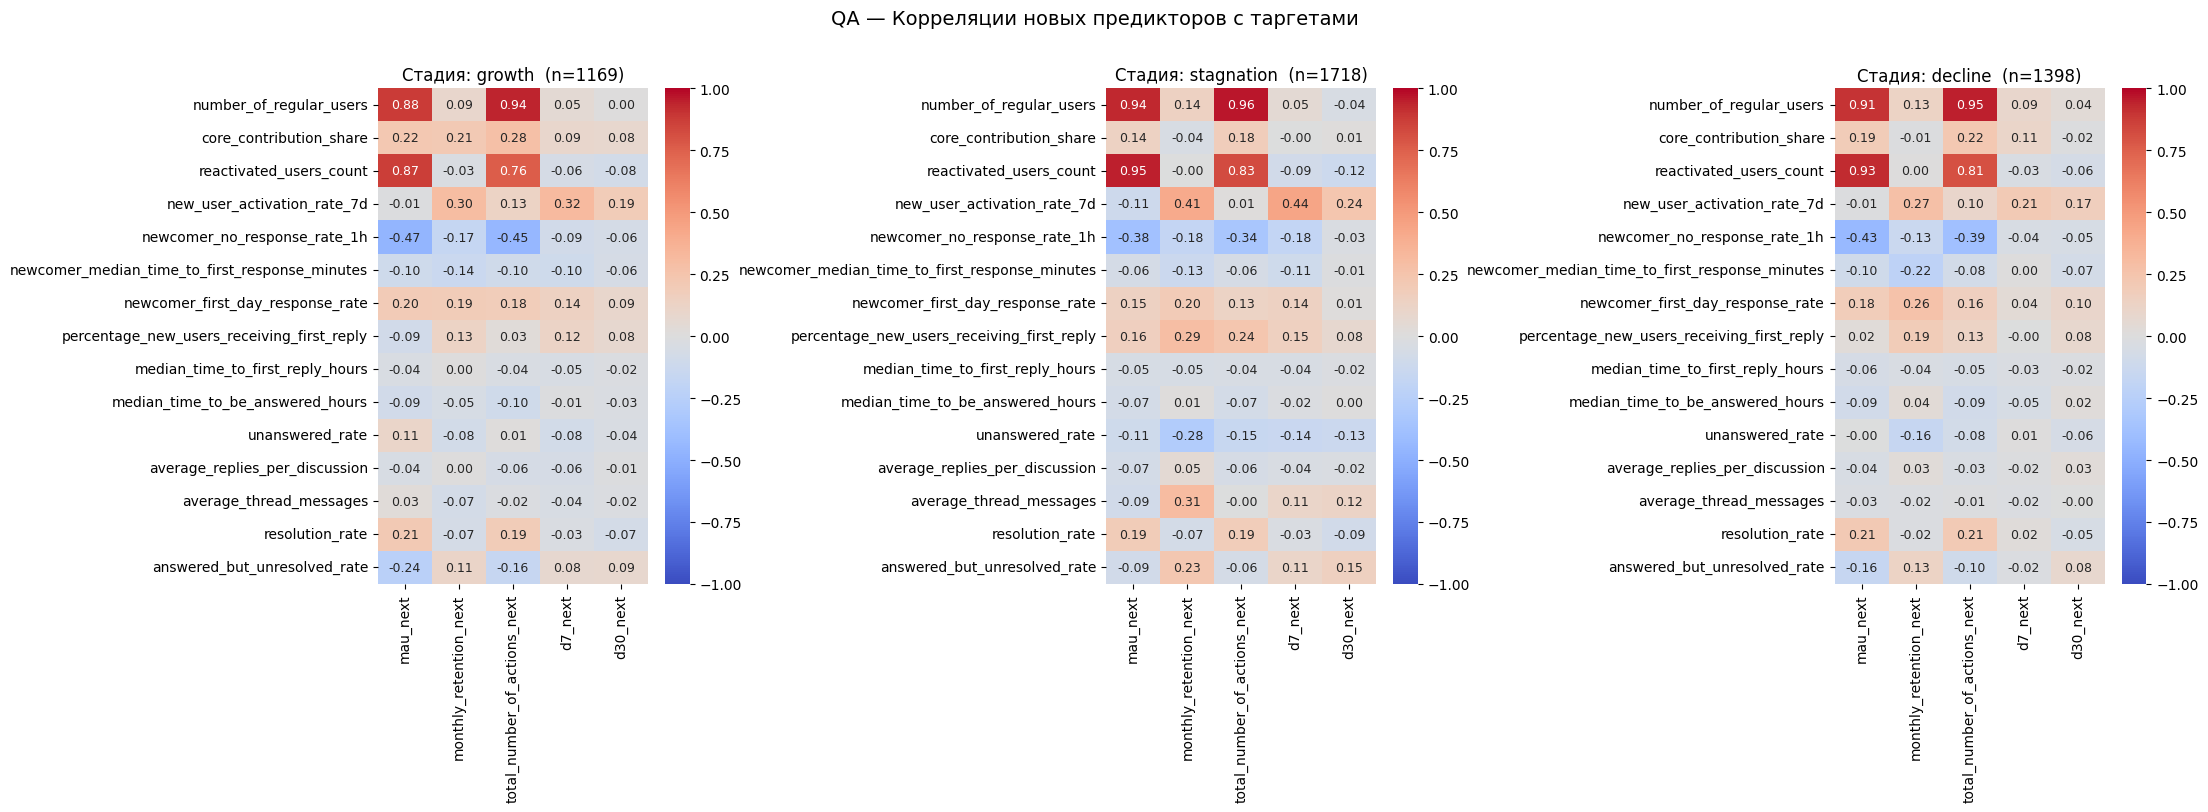

In [20]:
for community_type, df_type in [('QA', df_qa)]:
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    
    for i, stage in enumerate(stages):
        df_stage = df_type[df_type['stage'] == stage]
        
        corr = df_stage[predictors_qa + target_cols]\
            .corr(method='pearson')\
            .loc[predictors_qa, target_cols]
        
        n = len(df_stage)
        
        sns.heatmap(
            corr,
            annot=True, fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1, center=0,
            ax=axes[i],
            annot_kws={'size': 9}
        )
        axes[i].set_title(f'Стадия: {stage}  (n={n})', fontsize=12)
    
    plt.suptitle(f'{community_type.upper()} — Корреляции новых предикторов с таргетами',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

Те же проблемы что в chat — решение одинаковое
number_of_regular_users: 0.89–0.94 с MAU — часть-целое, убираем.
reactivated_users_count: 0.90–0.96 с MAU — ещё хуже чем в chat, заменяем на reactivated_rate.
core_contribution_share: слабее чем в chat (0.14–0.22), положительный — информационная метрика.
newcomer_median_time_to_first_response_minutes, median_time_to_first_reply_hours, median_time_to_be_answered_hours, average_replies_per_discussion: нет сигнала — убираем.

### 1. percentage_new_users_receiving_first_reply — работает иначе, чем в chat

| Стадия | monthly_retention | mau |
|--------|-------------------|-----|
| growth | 0.15 | -0.11 |
| stagnation | 0.28 | 0.15 |
| decline | 0.16 | 0.02 |

### 2. unanswered_rate — в Q&A правильный знак (в отличие от chat)

| Стадия | monthly_retention | mau |
|--------|-------------------|-----|
| growth | -0.11 | 0.13 |
| stagnation | -0.27 | -0.10 |
| decline | -0.12 | 0.00 |

### 3. resolution_rate — слабый, но стабильный положительный сигнал

| Стадия | mau | total_actions |
|--------|-----|----------------|
| growth | 0.21 | 0.19 |
| stagnation | 0.19 | 0.19 |
| decline | 0.22 | 0.21 |

### 4. answered_but_unresolved_rate — смешанные сигналы

| Стадия | mau | total_actions |
|--------|-----|----------------|
| growth | -0.05 | 0.17 |
| stagnation | 0.15 | 0.14 |
| decline | -0.12 | 0.04 |

### Общий итог по Q&A

| Метрика | Решение для Q&A |
|---------|------------------|
| percentage_new_users_receiving_first_reply | ✅ Оставляем |
| unanswered_rate | ✅ Оставляем |
| resolution_rate | ✅ Кандидат |
| answered_but_unresolved_rate | ❌ Убираем |

In [21]:
# Вместо абсолютного числа берём долю реактивированных от MAU
df_qa['reactivated_rate'] = (
    df_qa['reactivated_users_count'] / df_qa['mau']
)

df_qa['reactivated_rate'] = (
    df_qa['reactivated_users_count'] / df_qa['mau']
)

# Проверяем корреляцию с MAU после нормализации
print(df_qa[['reactivated_rate', 'mau']].corr())

                  reactivated_rate       mau
reactivated_rate          1.000000  0.087895
mau                       0.087895  1.000000


In [22]:
# Убираем всё что не прошло проверку для Q&A
to_drop_qa = [
    # Часть-целое с MAU
    'number_of_regular_users',
    # Заменяем на нормализованную версию
    'reactivated_users_count',
    # Информационная метрика — знак нелогичный для рекомендаций
    'core_contribution_share',
    # Нет сигнала
    'median_time_to_first_reply_hours',
    'median_time_to_be_answered_hours',
    'average_replies_per_discussion',
    # Нет сигнала, контринтуитивный знак
    'newcomer_median_time_to_first_response_minutes',
    # Мультиколлинеарность VIF > 6
    'newcomer_first_day_response_rate',
    # Нестабильно, смешанные знаки
    'answered_but_unresolved_rate',
]

predictors_qa = [p for p in predictors_qa if p not in to_drop_qa]

# Добавляем нормализованную версию reactivated
if 'reactivated_rate' not in predictors_qa:
    predictors_qa.append('reactivated_rate')

# В отличие от chat — оставляем эти три метрики
# percentage_new_users_receiving_first_reply — положительный сигнал на retention в stagnation
# unanswered_rate — правильный отрицательный знак на retention в stagnation
# resolution_rate — слабый но стабильный положительный сигнал во всех стадиях

print(predictors_qa)

['new_user_activation_rate_7d', 'newcomer_no_response_rate_1h', 'percentage_new_users_receiving_first_reply', 'unanswered_rate', 'average_thread_messages', 'resolution_rate', 'reactivated_rate']


Смотрим корреляции между таргетами

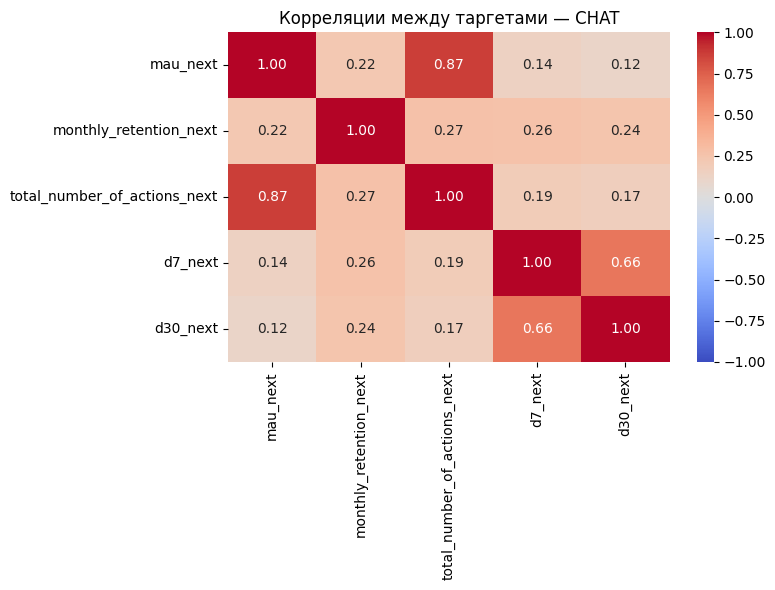

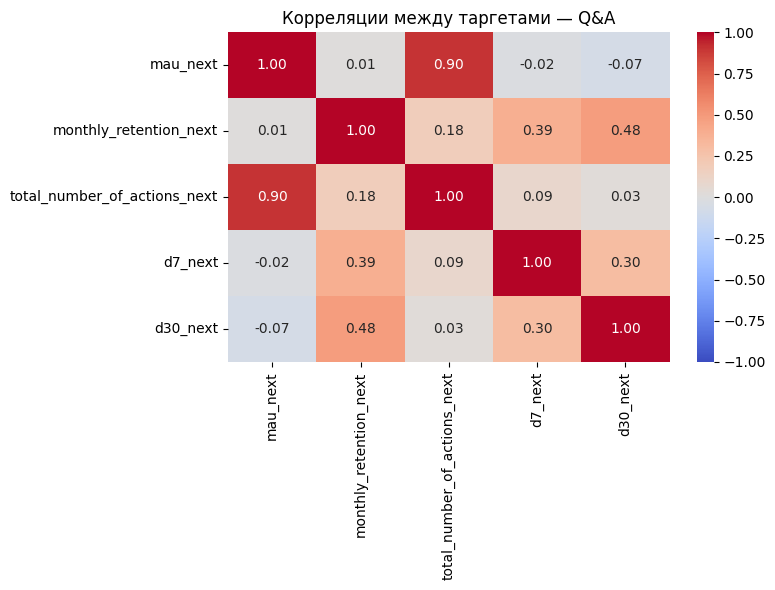

In [23]:
corr_targets = df_chat[target_cols].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_targets, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0)
plt.title('Корреляции между таргетами — CHAT')
plt.tight_layout()
plt.show()

# То же для Q&A
corr_targets_qa = df_qa[target_cols].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_targets_qa, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0)
plt.title('Корреляции между таргетами — Q&A')
plt.tight_layout()
plt.show()

In [24]:
targets = [
    'mau',                    # размер аудитории
    'monthly_retention',      # удержание всех пользователей
    'd7',                     # удержание новичков 7 дней
    'd30',                    # удержание новичков 30 дней
]
target_cols = [f'{t}_next' for t in targets]
# Убираем
# total_number_of_actions — дубликат mau (0.87-0.90)

In [25]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

results = []

for community_type, df_type, pred_list in [
    ('chat', df_chat, predictors_chat),
    ('qa', df_qa, predictors_qa),
]:
    for stage in ['growth', 'stagnation', 'decline']:
        df_stage = df_type[df_type['stage'] == stage].copy()
        
        for target in target_cols:
            df_train = df_stage.dropna(subset=pred_list + [target])
            
            if len(df_train) < 30:
                print(
                    f"Пропускаем {community_type}/{stage}/{target} — "
                    f"мало данных ({len(df_train)})"
                )
                continue
            
            X = df_train[pred_list]
            y = df_train[target]
            
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model', Ridge(alpha=1.0))
            ])
            
            pipe.fit(X, y)
            y_pred = pipe.predict(X)
            
            r2 = r2_score(y, y_pred)
            coefs = dict(zip(pred_list, pipe['model'].coef_))
            
            results.append({
                'type': community_type,
                'stage': stage,
                'target': target,
                'n': len(df_train),
                'r2': round(r2, 3),
                **{f'coef_{k}': round(v, 4) for k, v in coefs.items()}
            })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

type      stage                 target    n    r2  coef_new_user_activation_rate_7d  coef_newcomer_no_response_rate_1h  coef_average_replies_per_discussion  coef_average_thread_messages  coef_reactivated_rate  coef_percentage_new_users_receiving_first_reply  coef_unanswered_rate  coef_resolution_rate
chat     growth               mau_next  250 0.339                            9.1298                          -385.6614                             -28.0254                      -98.7960              -153.2591                                              NaN                   NaN                   NaN
chat     growth monthly_retention_next  250 0.103                            0.7980                            -3.4422                               0.9936                        3.6521                -3.4653                                              NaN                   NaN                   NaN
chat     growth                d7_next  244 0.125                            1.3838           

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def check_vif(df, predictors):
    X = df[predictors].dropna()
    vif_data = pd.DataFrame({
        'feature': predictors,
        'VIF': [variance_inflation_factor(X.values, i)
                for i in range(len(predictors))]
    })
    return vif_data.sort_values('VIF', ascending=False)

print("=== CHAT ===")
print(check_vif(df_chat.dropna(subset=predictors_chat), predictors_chat))

print("\n=== Q&A ===")
print(check_vif(df_qa.dropna(subset=predictors_qa), predictors_qa))

=== CHAT ===
                          feature       VIF
4                reactivated_rate  3.043471
3         average_thread_messages  2.156228
1    newcomer_no_response_rate_1h  1.896278
0     new_user_activation_rate_7d  1.888576
2  average_replies_per_discussion  1.243338

=== Q&A ===
                                      feature        VIF
2  percentage_new_users_receiving_first_reply  17.982166
0                 new_user_activation_rate_7d  11.019947
6                            reactivated_rate   4.980797
4                     average_thread_messages   2.419492
3                             unanswered_rate   1.862889
5                             resolution_rate   1.841252
1                newcomer_no_response_rate_1h   1.623091


| Предиктор | VIF | Решение |
|-----------|-----|---------|
| percentage_new_users_receiving_first_reply | 17.98 | ❌ убираем |
| new_user_activation_rate_7d | 11.02 | ⚠️ проверить после удаления первого |
| reactivated_rate | 4.98 | ✅ норма |
| Остальные | < 2.5 | ✅ норма |

In [27]:
predictors_qa = [p for p in predictors_qa 
                 if p != 'percentage_new_users_receiving_first_reply']

print("=== Q&A после удаления ===")
print(check_vif(df_qa.dropna(subset=predictors_qa), predictors_qa))

=== Q&A после удаления ===
                        feature       VIF
0   new_user_activation_rate_7d  3.719939
5              reactivated_rate  3.415376
2               unanswered_rate  1.754766
4               resolution_rate  1.737950
1  newcomer_no_response_rate_1h  1.357990
3       average_thread_messages  1.208044


Переобучаем модель

In [28]:
results = []

for community_type, df_type, pred_list in [
    ('chat', df_chat, predictors_chat),
    ('qa', df_qa, predictors_qa),
]:
    for stage in ['growth', 'stagnation', 'decline']:
        df_stage = df_type[df_type['stage'] == stage].copy()
        
        for target in target_cols:
            df_train = df_stage.dropna(subset=pred_list + [target])
            
            if len(df_train) < 30:
                print(
                    f"Пропускаем {community_type}/{stage}/{target} — "
                    f"мало данных ({len(df_train)})"
                )
                continue
            
            X = df_train[pred_list]
            y = df_train[target]
            
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model', Ridge(alpha=1.0))
            ])
            
            pipe.fit(X, y)
            y_pred = pipe.predict(X)
            
            r2 = r2_score(y, y_pred)
            coefs = dict(zip(pred_list, pipe['model'].coef_))
            
            results.append({
                'type': community_type,
                'stage': stage,
                'target': target,
                'n': len(df_train),
                'r2': round(r2, 3),
                **{f'coef_{k}': round(v, 4) for k, v in coefs.items()}
            })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

type      stage                 target    n    r2  coef_new_user_activation_rate_7d  coef_newcomer_no_response_rate_1h  coef_average_replies_per_discussion  coef_average_thread_messages  coef_reactivated_rate  coef_unanswered_rate  coef_resolution_rate
chat     growth               mau_next  250 0.339                            9.1298                          -385.6614                             -28.0254                      -98.7960              -153.2591                   NaN                   NaN
chat     growth monthly_retention_next  250 0.103                            0.7980                            -3.4422                               0.9936                        3.6521                -3.4653                   NaN                   NaN
chat     growth                d7_next  244 0.125                            1.3838                            -0.1068                               2.4957                       -1.1566                -0.7451                   NaN           

# Создаем Baseline модель

In [29]:
R2_THRESHOLD = 0.15

recommendation_map = {
    'chat': {
        'mau_next': [
            'newcomer_no_response_rate_1h',
            'new_user_activation_rate_7d',
        ],
        'monthly_retention_next': [
            'newcomer_no_response_rate_1h',
            'average_thread_messages',
            'average_replies_per_discussion',
        ],
    },
    'qa': {
        'mau_next': [
            'newcomer_no_response_rate_1h',
            'reactivated_rate',
            'resolution_rate',
        ],
        'monthly_retention_next': [
            'newcomer_no_response_rate_1h',
            'new_user_activation_rate_7d',
            'average_thread_messages',
        ],
    },
}

predictor_direction = {
    'newcomer_no_response_rate_1h':   'decrease',
    'new_user_activation_rate_7d':    'increase',
    'average_thread_messages':        'increase',
    'average_replies_per_discussion': 'increase',
    'reactivated_rate':               'increase',
    'unanswered_rate':                'decrease',
    'resolution_rate':                'increase',
}

predictor_labels = {
    'newcomer_no_response_rate_1h':   'Доля новичков без ответа за 1 час',
    'new_user_activation_rate_7d':    'Активация новичков за 7 дней',
    'average_thread_messages':        'Среднее сообщений в треде',
    'average_replies_per_discussion': 'Среднее ответов на обсуждение',
    'reactivated_rate':               'Доля реактивированных пользователей',
    'unanswered_rate':                'Доля вопросов без ответа',
    'resolution_rate':                'Доля решённых вопросов',
}

target_labels = {
    'mau_next':               'MAU следующего месяца',
    'monthly_retention_next': 'Retention следующего месяца',
    'd7_next':                'D7 Retention следующего месяца',
}

models    = {}
r2_scores = {}
scalers   = {}

for community_type, df_type, pred_list in [
    ('chat', df_chat, predictors_chat),
    ('qa',   df_qa,   predictors_qa),
]:
    for stage in ['growth', 'stagnation', 'decline']:
        df_stage = df_type[df_type['stage'] == stage].copy()

        sc = StandardScaler().fit(
            df_stage[pred_list].dropna()
        )
        scalers[(community_type, stage)] = sc

        for target in target_cols:
            df_train = df_stage.dropna(subset=pred_list + [target])

            if len(df_train) < 30:
                continue

            X = df_train[pred_list]
            y = df_train[target]

            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model',  Ridge(alpha=1.0))
            ])
            pipe.fit(X, y)

            r2 = r2_score(y, pipe.predict(X))
            models[(community_type, stage, target)]    = pipe
            r2_scores[(community_type, stage, target)] = round(r2, 3)

print("Модели обучены:")
for key, r2 in r2_scores.items():
    flag = "✅" if r2 >= R2_THRESHOLD else "❌"
    print(f"  {key[0]:6} / {key[1]:12} / {key[2]:25} r²={r2} {flag}")

Модели обучены:
  chat   / growth       / mau_next                  r²=0.339 ✅
  chat   / growth       / monthly_retention_next    r²=0.103 ❌
  chat   / growth       / d7_next                   r²=0.125 ❌
  chat   / growth       / d30_next                  r²=0.024 ❌
  chat   / stagnation   / mau_next                  r²=0.291 ✅
  chat   / stagnation   / monthly_retention_next    r²=0.392 ✅
  chat   / stagnation   / d7_next                   r²=0.161 ✅
  chat   / stagnation   / d30_next                  r²=0.145 ❌
  chat   / decline      / mau_next                  r²=0.301 ✅
  chat   / decline      / monthly_retention_next    r²=0.21 ✅
  chat   / decline      / d7_next                   r²=0.078 ❌
  chat   / decline      / d30_next                  r²=0.045 ❌
  qa     / growth       / mau_next                  r²=0.255 ✅
  qa     / growth       / monthly_retention_next    r²=0.111 ❌
  qa     / growth       / d7_next                   r²=0.106 ❌
  qa     / growth       / d30_next      

считаем бенчмарки
Идея: если 25% похожих сообществ уже достигли этого уровня — значит это реально достижимо.

In [30]:
benchmarks = {}

for community_type, df_type, pred_list in [
    ('chat', df_chat, predictors_chat),
    ('qa',   df_qa,   predictors_qa),
]:
    for stage in ['growth', 'stagnation', 'decline']:
        df_stage = df_type[df_type['stage'] == stage]

        for predictor in pred_list:
            vals = df_stage[predictor].dropna()
            benchmarks[(community_type, stage, predictor)] = {
                'p25':  round(vals.quantile(0.25), 4),
                'p50':  round(vals.quantile(0.50), 4),
                'p75':  round(vals.quantile(0.75), 4),
                'mean': round(vals.mean(), 4),
            }

print("Бенчмарки рассчитаны")

Бенчмарки рассчитаны


In [31]:
# ── 3. РЕКОМЕНДАТЕЛЬНАЯ ФУНКЦИЯ ──────────────────────────────────────
#
# ЛОГИКА РАБОТЫ
# =============
#
# Входные данные:
#   community_id    — название сообщества
#   community_type  — 'chat' или 'qa'
#   stage           — стадия: 'growth', 'stagnation', 'decline'
#   current_values  — словарь текущих значений предикторов за выбранный месяц
#
# Шаг 1 — Фильтрация моделей
#   Для каждого таргета (mau_next, monthly_retention_next, d7_next)
#   проверяем R² модели. Если R² < 0.15 — модель ненадёжна, пропускаем.
#
# Шаг 2 — Карта применимости
#   Не все предикторы используются для всех таргетов.
#   Используем только те пары (предиктор, таргет) у которых
#   корректный знак коэффициента по результатам анализа.
#
# Шаг 3 — Проверка потенциала и целевое значение
#   Для каждого допустимого предиктора сравниваем текущее значение
#   с целевым бенчмарком:
#     - decrease-метрики: цель = p25, но не ниже p1
#       (защита от нереалистичных целей, например цель = 0.0)
#     - increase-метрики: цель = p75
#   Если текущее значение уже лучше цели — пропускаем.
#
# Шаг 4 — Ограничение дельты (2 стандартных отклонения)
#   Модель обучена на типичных значениях предикторов.
#   Если текущее значение сильно выходит за пределы обучающей выборки,
#   линейная экстраполяция даёт нереальные эффекты (например +4841 MAU
#   для сообщества с 100% новичков без ответа).
#   Ограничиваем максимальное изменение предиктора двумя стандартными
#   отклонениями — это зона надёжной работы модели.
#   delta = clip(target_val - current_val, -2*std, +2*std)
#
# Шаг 5 — Расчёт эффекта
#   effect = coef × delta / std_predictor
#   Коэффициент взят из обученной Ridge-регрессии со стандартизацией.
#   std_predictor — из StandardScaler, обученного на той же выборке.
#
# Шаг 6 — Фильтрация по минимальному эффекту
#   Рекомендации с очень малым эффектом не несут практической ценности:
#     - MAU:              минимум 5 пользователей
#     - Retention / D7:   минимум 0.5 п.п.
#
# Шаг 7 — Дедупликация предикторов
#   Один предиктор может влиять на несколько таргетов одновременно.
#   После сортировки по убыванию эффекта оставляем только первое
#   вхождение каждого предиктора — менеджер видит одно конкретное
#   действие, а не повтор для разных таргетов.
#
# Шаг 8 — Ранжирование и вывод
#   Выдаём топ-N рекомендаций с указанием:
#     - текущего значения и его перцентиля среди похожих сообществ
#     - целевого значения (бенчмарк)
#     - ожидаемого изменения таргета
#     - R² модели

from scipy import stats
import numpy as np

# Пороги
MIN_EFFECT_MAU       = 5.0   # пользователей
MIN_EFFECT_RETENTION = 0.5   # процентных пунктов
MAX_DELTA_STD        = 2.0   # максимум отклонений от текущего значения


def get_current_percentile(current_val, community_type, stage, predictor):
    df_type = df_chat if community_type == 'chat' else df_qa
    vals    = df_type[df_type['stage'] == stage][predictor].dropna()
    return int(stats.percentileofscore(vals, current_val))


def get_target_value(bench, direction, df_type, stage, predictor):
    """
    Целевое значение предиктора:
      - decrease: p25, но не ниже p1
      - increase: p75
    """
    if direction == 'decrease':
        vals = df_type[df_type['stage'] == stage][predictor].dropna()
        p1   = round(vals.quantile(0.01), 4)
        return max(bench['p25'], p1)
    else:
        return bench['p75']


def clip_delta(delta, direction, df_type, stage, predictor):
    """
    Ограничивает изменение предиктора зоной надёжности модели.
    Максимальный шаг = MAX_DELTA_STD стандартных отклонений.
    """
    vals = df_type[df_type['stage'] == stage][predictor].dropna()
    std  = vals.std()
    max_step = MAX_DELTA_STD * std

    if direction == 'decrease':
        return max(delta, -max_step)   # delta отрицательная
    else:
        return min(delta, max_step)    # delta положительная


def get_recommendations(community_id, community_type, stage,
                        current_values: dict, top_n: int = 3):

    pred_list = predictors_chat if community_type == 'chat' else predictors_qa
    df_type   = df_chat if community_type == 'chat' else df_qa

    recommendations = []

    for target in target_cols:
        key = (community_type, stage, target)

        # Шаг 1 — фильтрация ненадёжных моделей
        if r2_scores.get(key, 0) < R2_THRESHOLD:
            continue

        pipe             = models[key]
        valid_predictors = recommendation_map[community_type].get(target, [])
        coefs            = dict(zip(pred_list, pipe['model'].coef_))
        sc               = scalers[(community_type, stage)]
        stds             = dict(zip(pred_list, sc.scale_))

        for predictor in valid_predictors:

            # Шаг 2 — проверка наличия данных
            if predictor not in current_values:
                continue
            if predictor not in stds:
                continue

            bench = benchmarks.get((community_type, stage, predictor))
            if bench is None:
                continue

            current_val = current_values[predictor]
            direction   = predictor_direction[predictor]

            # Шаг 3 — целевое значение
            target_val = get_target_value(
                bench, direction, df_type, stage, predictor
            )

            # Пропускаем если уже лучше цели
            if direction == 'decrease' and current_val <= target_val:
                continue
            if direction == 'increase' and current_val >= target_val:
                continue

            # Шаг 4 — ограничение дельты
            raw_delta    = target_val - current_val
            clipped_delta = clip_delta(
                raw_delta, direction, df_type, stage, predictor
            )

            # Пересчитываем target_val с учётом ограничения
            effective_target = round(current_val + clipped_delta, 4)

            # Шаг 5 — расчёт эффекта
            effect = coefs[predictor] * (clipped_delta / stds[predictor])

            # Шаг 6 — фильтрация по минимальному эффекту
            min_effect = MIN_EFFECT_MAU if 'mau' in target \
                         else MIN_EFFECT_RETENTION
            if abs(effect) < min_effect:
                continue

            recommendations.append({
                'target':           target,
                'predictor':        predictor,
                'current_val':      round(current_val, 4),
                'target_val':       effective_target,
                'original_target':  round(target_val, 4),
                'effect':           round(effect, 2),
                'r2':               r2_scores[key],
                'direction':        direction,
                'delta_capped':     clipped_delta != raw_delta,
            })

    if not recommendations:
        return (f"📊 {community_id} ({community_type}, {stage})\n"
                f"   Нет рекомендаций — метрики уже на целевом уровне\n")

    # Шаг 7 — сортировка и дедупликация предикторов
    recommendations = sorted(recommendations,
                             key=lambda x: abs(x['effect']),
                             reverse=True)

    seen_predictors = set()
    deduped = []
    for rec in recommendations:
        if rec['predictor'] not in seen_predictors:
            seen_predictors.add(rec['predictor'])
            deduped.append(rec)

    # Шаг 8 — формирование вывода
    output = [f"📊 Рекомендации для {community_id} "
              f"(тип: {community_type}, стадия: {stage})\n"]

    for i, rec in enumerate(deduped[:top_n], 1):
        direction_word = "снизить" if rec['direction'] == 'decrease' \
                         else "повысить"
        effect_word    = "+" if rec['effect'] > 0 else ""
        units          = "пользователей" if 'mau' in rec['target'] \
                         else "п.п."
        current_pct    = get_current_percentile(
            rec['current_val'], community_type, stage, rec['predictor']
        )

        # Добавляем пометку если дельта была ограничена
        cap_note = (f" (цель по бенчмарку: {rec['original_target']}, "
                    f"ограничено до 2σ)") if rec['delta_capped'] else ""

        output.append(
            f"{i}. {direction_word.upper()} "
            f"«{predictor_labels[rec['predictor']]}»\n"
            f"   Сейчас: {rec['current_val']} ({current_pct}й перцентиль) "
            f"→ Цель: {rec['target_val']}{cap_note}\n"
            f"   Эффект на {target_labels[rec['target']]}: "
            f"{effect_word}{rec['effect']} {units}\n"
            f"   (R²={rec['r2']})\n"
        )

    return "\n".join(output)

In [32]:
test_id_chat    = 'acer'
test_month_chat = '2023-10'

test_id_qa    = 'elastic'
test_month_qa = '2023-09'

def get_current_values(community_id, df, pred_list, month=None):
    df_comm = df[df['community_id'] == community_id].sort_values('month')

    if month:
        row = df_comm[df_comm['month'].astype(str) == month]
        if len(row) == 0:
            print(f"Месяц {month} не найден, берём последний")
            row = df_comm.iloc[[-1]]
    else:
        row = df_comm.iloc[[-1]]

    last_row = row.iloc[-1]
    return {p: last_row[p] for p in pred_list if pd.notna(last_row[p])}

# Определяем тип и стадию для Чата
test_type  = 'chat'
test_stage = df_chat[
    df_chat['community_id'] == test_id_chat
].sort_values('month').iloc[-1]['stage']

current_vals = get_current_values(test_id_chat, df_chat, predictors_chat, month=test_month_chat)

print(get_recommendations(test_id_chat, test_type, test_stage, current_vals))

test_stage_qa = df_qa[
    df_qa['community_id'] == test_id_qa
].sort_values('month').iloc[-1]['stage']

current_vals_qa = get_current_values(test_id_qa, df_qa, predictors_qa, month=test_month_qa)
print(get_recommendations(test_id_qa, 'qa', test_stage_qa, current_vals_qa))

📊 Рекомендации для acer (тип: chat, стадия: stagnation)

1. ПОВЫСИТЬ «Активация новичков за 7 дней»
   Сейчас: 0.0 (3й перцентиль) → Цель: 40.7674 (цель по бенчмарку: 54.4638, ограничено до 2σ)
   Эффект на MAU следующего месяца: +420.64 пользователей
   (R²=0.291)

2. СНИЗИТЬ «Доля новичков без ответа за 1 час»
   Сейчас: 33.3333 (71й перцентиль) → Цель: 0.1706
   Эффект на MAU следующего месяца: +366.78 пользователей
   (R²=0.291)

3. ПОВЫСИТЬ «Среднее сообщений в треде»
   Сейчас: 20.0 (72й перцентиль) → Цель: 24.0671
   Эффект на Retention следующего месяца: +1.23 п.п.
   (R²=0.392)

📊 Рекомендации для elastic (тип: qa, стадия: stagnation)

1. СНИЗИТЬ «Доля новичков без ответа за 1 час»
   Сейчас: 3.0612 (56й перцентиль) → Цель: 0.0
   Эффект на MAU следующего месяца: +148.2 пользователей
   (R²=0.272)

2. ПОВЫСИТЬ «Доля решённых вопросов»
   Сейчас: 16.4773 (62й перцентиль) → Цель: 23.1396
   Эффект на MAU следующего месяца: +107.68 пользователей
   (R²=0.272)

3. ПОВЫСИТЬ «Доля р

## Архитектура рекомендательной системы

### Общий принцип

Система использует лаговую структуру: значения предикторов текущего месяца 
предсказывают значения таргетов следующего месяца. Менеджер действует сейчас 
и получает прогноз на следующий период.

### Типы сообществ и стадии

Система работает раздельно для двух типов сообществ поскольку механизмы 
вовлечения в них принципиально различаются:
- **Q&A форумы** (20 сообществ) — вопросно-ответные платформы
- **Чаты** (10 сообществ) — чат-сообщества реального времени

Каждому месяцу наблюдения присваивается стадия жизненного цикла на основе 
темпа роста MAU:

| Стадия | Критерий | n (chat) | n (qa) |
|---|---|---|---|
| Growth | mau_mom > 10% | 283 | 1169 |
| Stagnation | -5% < mau_mom < 10% | 225 | 1718 |
| Decline | mau_mom < -5% | 313 | 1398 |

### Предикторы

Итоговые списки предикторов после корреляционного анализа, проверки знаков 
и теста на мультиколлинеарность (VIF < 5):

**Chat:**
- `newcomer_no_response_rate_1h` — доля новичков без ответа за 1 час
- `new_user_activation_rate_7d` — активация новичков за 7 дней
- `average_thread_messages` — среднее сообщений в треде
- `average_replies_per_discussion` — среднее ответов на обсуждение
- `reactivated_rate` — доля реактивированных пользователей от MAU

**Q&A:**
- `newcomer_no_response_rate_1h` — доля новичков без ответа за 1 час
- `new_user_activation_rate_7d` — активация новичков за 7 дней
- `average_thread_messages` — среднее сообщений в треде
- `unanswered_rate` — доля вопросов без ответа
- `resolution_rate` — доля решённых вопросов
- `reactivated_rate` — доля реактивированных пользователей от MAU

### Таргеты

| Таргет | Описание |
|---|---|
| `mau_next` | MAU следующего месяца |
| `monthly_retention_next` | Retention следующего месяца |
| `d7_next` | D7 Retention следующего месяца |

`d30_next` исключён — R² < 0.15 во всех стадиях и типах.

### Модели

Обучается **24 модели** (2 типа × 3 стадии × 4 таргета включая d30).
Из них **11 проходят порог надёжности** R² ≥ 0.15:

| | growth | stagnation | decline |
|---|---|---|---|
| chat / mau | ✅ 0.34 | ✅ 0.29 | ✅ 0.30 |
| chat / retention | ❌ 0.10 | ✅ 0.39 | ✅ 0.21 |
| chat / d7 | ❌ 0.13 | ✅ 0.16 | ❌ 0.08 |
| qa / mau | ✅ 0.26 | ✅ 0.27 | ✅ 0.22 |
| qa / retention | ❌ 0.11 | ✅ 0.29 | ✅ 0.21 |
| qa / d7 | ❌ 0.11 | ✅ 0.25 | ❌ 0.08 |

Для ячеек ❌ система выводит предупреждение вместо рекомендации.

### Алгоритм рекомендации

**Шаг 1 — Регрессионные модели**

Для каждой комбинации (тип, стадия, таргет) обучается Ridge-регрессия 
с предварительной стандартизацией предикторов. Стандартизация позволяет 
сравнивать коэффициенты между предикторами с разными единицами измерения.

**Шаг 2 — Карта применимости**

Не все предикторы используются для всех таргетов — только те, у которых 
корректный знак коэффициента по результатам анализа:

```python
recommendation_map = {
    'chat': {
        'mau_next':               ['newcomer_no_response_rate_1h', 
                                   'new_user_activation_rate_7d'],
        'monthly_retention_next': ['newcomer_no_response_rate_1h',
                                   'average_thread_messages',
                                   'average_replies_per_discussion'],
    },
    'qa': {
        'mau_next':               ['newcomer_no_response_rate_1h',
                                   'reactivated_rate', 'resolution_rate'],
        'monthly_retention_next': ['newcomer_no_response_rate_1h',
                                   'new_user_activation_rate_7d',
                                   'average_thread_messages'],
    },
}
```

**Шаг 3 — Бенчмарки**

Для каждого предиктора по каждой комбинации (тип, стадия) рассчитываются 
перцентили на обучающей выборке. Целевое значение — 75й перцентиль 
(для метрик на повышение) или 25й перцентиль (для метрик на снижение). 
Бенчмарк считается отдельно для каждого типа и стадии.

**Шаг 4 — Расчёт потенциала**

$$effect = coef \times \frac{target\_value - current\_value}{std\_predictor}$$

**Шаг 5 — Ранжирование**

Все рекомендации сортируются по абсолютному эффекту. Выдаётся топ-3 
с указанием текущего значения, перцентиля и ожидаемого изменения таргета.

### Различия между типами сообществ

| Предиктор | Chat | Q&A |
|---|---|---|
| `newcomer_no_response_rate_1h` | Влияет на MAU (-0.50) | Влияет на MAU (-0.47) |
| `new_user_activation_rate_7d` | Влияет на MAU (+0.37) | Влияет на Retention (+0.41) |
| `average_thread_messages` | Влияет на Retention (+0.35) | Влияет на Retention (+0.32) |

В чатах активация новичков конвертируется в MAU напрямую. В Q&A та же 
метрика влияет на удержание, но не на размер аудитории.

### Пример вывода

📊 Рекомендации для acer (тип: chat, стадия: stagnation)

1. ПОВЫСИТЬ «Активация новичков за 7 дней»
   Сейчас: 0.0 (3й перцентиль) → Цель: 54.4638
   Эффект на MAU следующего месяца: +561.96 пользователей
   (R²=0.291)

2. СНИЗИТЬ «Доля новичков без ответа за 1 час»
   Сейчас: 33.3333 (71й перцентиль) → Цель: 0.1706
   Эффект на MAU следующего месяца: +366.78 пользователей
   (R²=0.291)

## Текущее состояние и следующие шаги

### Сделано

- Сформирован панельный датасет по 36 сообществам (4521 наблюдение для Q&A, 
  1036 для чатов)
- Определены и рассчитаны все метрики
- Проведён корреляционный анализ по типам и стадиям, выявлены различия 
  в механизмах работы предикторов
- Проверены и устранены проблемы мультиколлинеарности (VIF < 5)
- Исключены предикторы с контринтуитивными знаками и часть-целое корреляцией 
  с MAU
- Обучены 24 модели, из которых 11 проходят порог надёжности R² ≥ 0.15
- Реализована рекомендательная функция с бенчмарками и перцентилями

### Следующие шаги

- **Валидация** — train/test split по времени, проверка R² на отложенной выборке
- **Калибровка бенчмарков** — оценка достижимости 75го перцентиля за один месяц
- **Проверка аномалий** — прогон по всем 36 сообществам, выявление выбросов 
  в рекомендациях (например значение 0.0 для активации новичков)
- **Упаковка** — API-функция принимающая community_id и возвращающая 
  структурированные рекомендации для фронтенда

# Пример использования
## Более юзер-френдли рекомендация
Ниже блок кода для обновления юзер-френдли рекомендации


In [33]:
from scipy import stats
import pandas as pd
import numpy as np

# ============================================================
# ФИНАЛЬНЫЙ БЛОК РЕКОМЕНДАЦИЙ
# Пользователь вводит только community_id и month
# ============================================================

MIN_EFFECT_MAU = 5.0
MIN_EFFECT_RETENTION = 0.5
MAX_DELTA_STD = 2.0

predictor_explanations = {
    'newcomer_no_response_rate_1h':
        'быстрый первый ответ повышает шанс, что новичок продолжит участвовать',
    'new_user_activation_rate_7d':
        'активация новичков показывает, что онбординг работает',
    'average_thread_messages':
        'более длинные обсуждения обычно связаны с более живым сообществом',
    'average_replies_per_discussion':
        'больше ответов на обсуждение означает выше вовлеченность',
    'reactivated_rate':
        'возврат неактивных пользователей поддерживает размер активной аудитории',
    'resolution_rate':
        'решенные вопросы повышают полезность сообщества',
    'unanswered_rate':
        'меньше вопросов без ответа снижает фрустрацию пользователей',
}

rate_metrics = {
    'newcomer_no_response_rate_1h',
    'new_user_activation_rate_7d',
    'reactivated_rate',
    'unanswered_rate',
    'resolution_rate',
    'monthly_retention',
    'monthly_retention_next',
    'd7',
    'd7_next',
}

def to_percent_value(value):
    if pd.isna(value):
        return np.nan
    if abs(value) <= 1.5:
        return value * 100
    return value

def fmt_value(metric, value):
    if pd.isna(value):
        return 'нет данных'

    if metric in rate_metrics:
        return f'{to_percent_value(value):.1f}%'

    if metric == 'mau_next':
        return f'{value:,.0f}'.replace(',', ' ')

    return f'{value:.2f}'

def fmt_effect(target, effect, current_mau=None):
    if target == 'mau_next':
        base_text = f'{effect:+.0f} пользователей к MAU следующего месяца'

        if current_mau is not None and not pd.isna(current_mau) and current_mau != 0:
            effect_pct = effect / current_mau * 100
            return f'{base_text} ({effect_pct:+.1f}% от текущего MAU)'

        return base_text

    return f'{to_percent_value(effect):+.2f} п.п. к {target_labels.get(target, target)}'


def r2_label(r2):
    if r2 >= 0.50:
        return 'сильная историческая связь'
    if r2 >= 0.25:
        return 'умеренная историческая связь'
    return 'слабая историческая связь'

def action_text(predictor):
    label = predictor_labels.get(predictor, predictor)
    direction = predictor_direction[predictor]

    if direction == 'decrease':
        return f'Снизить: {label}'

    return f'Увеличить: {label}'

def get_current_percentile(current_val, community_type, stage, predictor):
    df_type = df_chat if community_type == 'chat' else df_qa
    vals = df_type[df_type['stage'] == stage][predictor].dropna()

    if len(vals) == 0 or pd.isna(current_val):
        return None

    return int(stats.percentileofscore(vals, current_val))

def get_target_value(bench, direction, df_type, stage, predictor):
    if direction == 'decrease':
        vals = df_type[df_type['stage'] == stage][predictor].dropna()

        if len(vals) == 0:
            return bench['p25']

        p1 = vals.quantile(0.01)
        return max(bench['p25'], p1)

    return bench['p75']

def clip_delta(delta, direction, df_type, stage, predictor):
    vals = df_type[df_type['stage'] == stage][predictor].dropna()
    std = vals.std()

    if pd.isna(std) or std == 0:
        return delta

    max_step = MAX_DELTA_STD * std

    if direction == 'decrease':
        return max(delta, -max_step)

    return min(delta, max_step)

def detect_community_type(community_id, month):
    month = str(month)

    chat_rows = df_chat[
        (df_chat['community_id'] == community_id) &
        (df_chat['month'].astype(str) == month)
    ]

    qa_rows = df_qa[
        (df_qa['community_id'] == community_id) &
        (df_qa['month'].astype(str) == month)
    ]

    found_in_chat = len(chat_rows) > 0
    found_in_qa = len(qa_rows) > 0

    if found_in_chat and not found_in_qa:
        return 'chat', chat_rows.iloc[0]

    if found_in_qa and not found_in_chat:
        return 'qa', qa_rows.iloc[0]

    if not found_in_chat and not found_in_qa:
        raise ValueError(
            f'Не найдено сообщество={community_id}, месяц={month}'
        )

    chat_filled = chat_rows.iloc[0][predictors_chat].notna().sum()
    qa_filled = qa_rows.iloc[0][predictors_qa].notna().sum()

    if chat_filled >= qa_filled:
        return 'chat', chat_rows.iloc[0]

    return 'qa', qa_rows.iloc[0]

def build_recommendations(community_id, community_type, stage, current_values, top_n=3):
    pred_list = predictors_chat if community_type == 'chat' else predictors_qa
    df_type = df_chat if community_type == 'chat' else df_qa

    recommendations = []
    skipped = []

    for target in target_cols:
        key = (community_type, stage, target)

        if key not in models:
            skipped.append(f'{target}: нет обученной модели')
            continue

        r2 = r2_scores.get(key, 0)

        if r2 < R2_THRESHOLD:
            skipped.append(f'{target}: R² ниже порога ({r2:.3f} < {R2_THRESHOLD})')
            continue

        pipe = models[key]
        valid_predictors = recommendation_map[community_type].get(target, [])

        coefs = dict(zip(pred_list, pipe['model'].coef_))
        sc = scalers[(community_type, stage)]
        stds = dict(zip(pred_list, sc.scale_))

        for predictor in valid_predictors:
            if predictor not in current_values:
                continue

            current_val = current_values[predictor]

            if pd.isna(current_val):
                continue

            bench = benchmarks.get((community_type, stage, predictor))

            if bench is None:
                continue

            if predictor not in coefs or predictor not in stds:
                continue

            if stds[predictor] == 0:
                continue

            direction = predictor_direction[predictor]

            target_val = get_target_value(
                bench=bench,
                direction=direction,
                df_type=df_type,
                stage=stage,
                predictor=predictor
            )

            if direction == 'decrease' and current_val <= target_val:
                continue

            if direction == 'increase' and current_val >= target_val:
                continue

            raw_delta = target_val - current_val

            clipped_delta = clip_delta(
                delta=raw_delta,
                direction=direction,
                df_type=df_type,
                stage=stage,
                predictor=predictor
            )

            effective_target = current_val + clipped_delta
            effect = coefs[predictor] * (clipped_delta / stds[predictor])

            if target == 'mau_next':
                if abs(effect) < MIN_EFFECT_MAU:
                    continue
            else:
                if abs(to_percent_value(effect)) < MIN_EFFECT_RETENTION:
                    continue

            percentile = get_current_percentile(
                current_val=current_val,
                community_type=community_type,
                stage=stage,
                predictor=predictor
            )

            recommendations.append({
                'community_id': community_id,
                'community_type': community_type,
                'stage': stage,
                'target': target,
                'predictor': predictor,
                'current_value': current_val,
                'target_value': effective_target,
                'raw_target_value': target_val,
                'delta': clipped_delta,
                'effect': effect,
                'r2': r2,
                'percentile': percentile,
                'current_mau': current_values.get('mau', np.nan),
            })

    recommendations = sorted(
        recommendations,
        key=lambda x: (
            abs(x['effect'])
            if x['target'] == 'mau_next'
            else abs(to_percent_value(x['effect']))
        ),
        reverse=True
    )

    unique_recommendations = []
    used_predictors = set()

    for rec in recommendations:
        if rec['predictor'] in used_predictors:
            continue

        unique_recommendations.append(rec)
        used_predictors.add(rec['predictor'])

        if len(unique_recommendations) >= top_n:
            break

    return unique_recommendations, skipped

def render_recommendations(community_id, community_type, stage, month, recommendations, skipped=None):
    lines = [
        f'Сообщество: {community_id}',
        f'Месяц: {month}',
        f'Тип: {community_type}',
        f'Стадия: {stage}',
        ''
    ]

    if not recommendations:
        lines.extend([
            'Рекомендации не найдены.',
            '',
            'Возможные причины:',
            '- модель ниже порога R²',
            '- метрики уже находятся на хорошем уровне',
            '- нет данных за выбранный месяц',
            '- ожидаемый эффект слишком мал',
        ])

        if skipped:
            lines.append('')
            lines.append('Проверка моделей:')
            for item in skipped:
                lines.append(f'- {item}')

        return '\n'.join(lines)

    lines.append(f'Найдено действий: {len(recommendations)}')
    lines.append('')

    for i, rec in enumerate(recommendations, 1):
        predictor = rec['predictor']
        target = rec['target']
        percentile = rec['percentile']

        percentile_text = ''
        if percentile is not None:
            percentile_text = f' ({percentile}-й перцентиль среди похожих месяцев)'

        lines.extend([
            f'{i}. {action_text(predictor)}',
            f'   Сейчас: {fmt_value(predictor, rec["current_value"])}{percentile_text}',
            f'   Ориентир: {fmt_value(predictor, rec["target_value"])}',
            f'   Почему: {predictor_explanations.get(predictor, "метрика связана с целевым показателем")}.',
            f'   Ожидаемый эффект: {fmt_effect(target, rec["effect"], rec.get("current_mau"))}',
            f'   Модель: R² train = {rec["r2"]:.3f}, {r2_label(rec["r2"])}',
            ''
        ])

    lines.append(
        'Важно: это baseline без валидации. R² показывает историческую связь '
        'на обучающих данных, а не гарантированную точность прогноза.'
    )

    return '\n'.join(lines)

def recommend_for_community_month(community_id, month, top_n=3, return_df=False):
    community_type, row = detect_community_type(
        community_id=community_id,
        month=month
    )

    df_type = df_chat if community_type == 'chat' else df_qa
    pred_list = predictors_chat if community_type == 'chat' else predictors_qa

    stage = row['stage']

    current_values = {
        predictor: row[predictor]
        for predictor in pred_list
        if predictor in row.index
    }

    recommendations, skipped = build_recommendations(
        community_id=community_id,
        community_type=community_type,
        stage=stage,
        current_values=current_values,
        top_n=top_n
    )

    text = render_recommendations(
        community_id=community_id,
        community_type=community_type,
        stage=stage,
        month=month,
        recommendations=recommendations,
        skipped=skipped
    )

    print(text)

    if return_df:
        return pd.DataFrame(recommendations)


Демо-версия
community_id - задать сообщество
month - задать месяц для которого смотреть прогноз

Общий список всех сообществ:
acer
ageofempires
blenderartists
brave
elastic
envato
eveonline
fatsharkgames
figma
forums.developer.nvidia.com
freecodecamp
funcom
google
infiniteflight
ionicframework
jitsi
manjaro
mcneel
n8n
obsidian
openai
openhab
opensuse
openwrt
plex
python
roblox
sheknows
shopify
spiceworks
straightdope
unity
unrealengine
warthunder
wd
wyze

In [34]:
recommend_for_community_month(
    community_id='acer',
    month='2023-01',
    top_n=3
)


Сообщество: acer
Месяц: 2023-01
Тип: chat
Стадия: decline

Найдено действий: 3

1. Снизить: Доля новичков без ответа за 1 час
   Сейчас: 16.7% (35-й перцентиль среди похожих месяцев)
   Ориентир: 4.1%
   Почему: быстрый первый ответ повышает шанс, что новичок продолжит участвовать.
   Ожидаемый эффект: +120 пользователей к MAU следующего месяца
   Модель: R² train = 0.301, умеренная историческая связь

2. Увеличить: Активация новичков за 7 дней
   Сейчас: 8.3% (22-й перцентиль среди похожих месяцев)
   Ориентир: 47.9%
   Почему: активация новичков показывает, что онбординг работает.
   Ожидаемый эффект: +41 пользователей к MAU следующего месяца
   Модель: R² train = 0.301, умеренная историческая связь

3. Увеличить: Среднее сообщений в треде
   Сейчас: 26.00 (70-й перцентиль среди похожих месяцев)
   Ориентир: 34.14
   Почему: более длинные обсуждения обычно связаны с более живым сообществом.
   Ожидаемый эффект: +1.66 п.п. к Retention следующего месяца
   Модель: R² train = 0.210, сла